#  Exploración del espacio de estados de un cúbit

La Esfera de Bloch es una representación geométrica fundamental en la computación cuántica que permite visualizar el estado de un sistema de un solo cúbit. A diferencia de un bit clásico, que solo puede tomar valores discretos (0 o 1), un cúbit puede hallarse en una superposición coherente de ambos estados, representándose como un punto sobre la superficie de una esfera de radio unidad.

## Objetivos de la actividad:

- **Representación Geométrica**: Desarrollar una herramienta visual que mapee estados cuánticos complejos en un espacio tridimensional (x, y, z).

- **Simulación de Puertas Cuánticas**: Visualizar el impacto de diversos operadores unitarios como Hadamard, Paulis, rotaciones de fase y raíces cuadradas sobre el vector de estado.

 - **Interactividad**: Implementar una interfaz que permita modificar los parámetros de entrada (Theta y Phi) para observar en tiempo real la evolución del sistema.

Cualquier estado puro de un cúbit puede escribirse mediante la combinación lineal de los estados base, donde Theta representa el ángulo polar y Phi la fase relativa o ángulo azimutal. El propósito de este Trabajo visualizar estas operaciones matemáticas de una forma intuitiva y dinámica.

## Instalación de dependencias.
*Es importante reiniciar el Kernel tras las instalación*

In [1]:
%pip install qiskit qiskit-aer matplotlib numpy ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import ipywidgets as widgets
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import numpy as np 

%matplotlib inline

## Visualización de Esfera de Bloch
Implementación manual mediante Matplotlib para representar estados cuánticos en el espacio 3D sin depender de funciones predefinidas de Qiskit.

In [2]:
def plot_bloch_from_scratch(x, y, z, title="Cúbit en la Esfera de Bloch", ax=None):
    """
    Dibuja una esfera de Bloch aceptando un eje opcional para subplots.
    """
    # --- 1. Configuración del Entorno 3D ---
    # Si no nos pasan un eje, creamos una figura nueva
    if ax is None:
        fig = plt.figure(figsize=(8, 8))
        ax = fig.add_subplot(111, projection='3d')
    
    ax.set_aspect('equal')

    # --- 2. Creación de la Esfera Traslúcida ---
    u = np.linspace(0, 2 * np.pi, 50) # Reducimos puntos para que cargue más rápido
    v = np.linspace(0, np.pi, 50)
    x_sphere = np.outer(np.cos(u), np.sin(v))
    y_sphere = np.outer(np.sin(u), np.sin(v))
    z_sphere = np.outer(np.ones(np.size(u)), np.cos(v))
    ax.plot_wireframe(x_sphere, y_sphere, z_sphere, color='gray', alpha=0.1, linewidth=0.5)

    # --- 3. Ejes de Referencia ---
    limit = 1.1
    ax.plot([0, 0], [0, 0], [-limit, limit], color='black', linestyle='--', linewidth=0.8)
    ax.plot([-limit, limit], [0, 0], [0, 0], color='black', linestyle='--', linewidth=0.8)
    ax.plot([0, 0], [-limit, limit], [0, 0], color='black', linestyle='--', linewidth=0.8)

    # Etiquetas
    ax.text(0, 0, limit + 0.1, r'$|0\rangle$', color='black', fontsize=10, ha='center')
    ax.text(0, 0, -limit - 0.2, r'$|1\rangle$', color='black', fontsize=10, ha='center')

    # --- 4. Vector de Estado ---
    ax.scatter([x], [y], [z], color='blue', s=50)
    ax.quiver(0, 0, 0, x, y, z, color='blue', length=1.0, arrow_length_ratio=0.15, linewidth=2)

    # --- 5. Limpieza ---
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.set_xlim([-limit, limit]); ax.set_ylim([-limit, limit]); ax.set_zlim([-limit, limit])
    ax.grid(False)

## Integración con Qiskit

Esta sección gestiona la lógica cuántica y la transformación de datos para la simulación.

### Componentes del Sistema:

* **Preparación del Estado (`crear_estado_qubit`):** Implementa la parametrización matemática de un cúbit en la esfera de Bloch.
* **Gestión del Circuito (`crear_quantum_circuit`):** Utiliza la librería **Qiskit** para instanciar el circuito cuántico.
* **Manipulación y Evolución (`obtener_estado_final`):** Ejecuta las puertas cuánticas solicitadas (H, Paulis, S, T, V) sobre el circuito.
* **Proyección Geométrica (`get_bloch_coordinates`):** Transforma el vector de estado (espacio de Hilbert) a coordenadas cartesianas $(x, y, z)$ mediante los valores esperados de los operadores de Pauli.
* **Visualización (`visualizar_estado`):** Actúa como interfaz entre el motor lógico y el motor de renderizado 3D manual.
* **Ejecutor de la simulación (simular_qbit):**  Centraliza el flujo de trabajo siguiendo un patrón de pipeline de datos. Esta función coordina la ingesta de parámetros, la transformación cuántica, el mapeo de coordenadas y el renderizado final de la esfera.

In [3]:
def visualizar_estado(theta_deg, phi_deg, titulo=""):
    """
    Toma ángulos en grados, los convierte a coordenadas cartesianas 
    y utiliza la función de dibujo manual para representar el punto en la esfera.
    """
    # Conversión a radianes
    theta = np.radians(theta_deg)
    phi = np.radians(phi_deg)
    
    # Cálculo de coordenadas cartesianas desde ángulos esféricos
    x = np.sin(theta) * np.cos(phi)
    y = np.sin(theta) * np.sin(phi)
    z = np.cos(theta)
    
    # Llamada a la función de dibujo
    plot_bloch_from_scratch(x, y, z, title=titulo)

def get_bloch_coordinates(statevector):
    """
    Calcula los valores de expectación de los observables de Pauli (X, Y, Z) 
    para mapear un Statevector de Qiskit al espacio tridimensional de la esfera.
    """
    # Se extraen las amplitudes alpha (para |0>) y beta (para |1>)
    alpha = statevector.data[0]
    beta = statevector.data[1]
    
    # x = <psi|X|psi>, y = <psi|Y|psi>, z = <psi|Z|psi>
    x = 2 * np.real(np.conj(alpha) * beta)
    y = 2 * np.imag(np.conj(alpha) * beta)
    z = np.abs(alpha)**2 - np.abs(beta)**2
    
    return x, y, z

def crear_estado_qubit(theta_deg, phi_deg):
    """
    Genera un vector de estado normalizado aplicando la parametrización:
    |psi> = cos(theta/2)|0> + e^(i*phi)sin(theta/2)|1>
    """
    # Normalización de ángulos para evitar desbordamientos y conversión a radianes
    theta_rad = np.radians(theta_deg % 360)
    phi_rad = np.radians(phi_deg % 360)
    
    # Amplitudes complejas
    alpha = np.cos(theta_rad / 2)
    beta = np.exp(1j * phi_rad) * np.sin(theta_rad / 2)
    
    return Statevector([alpha, beta])

def crear_quantum_circuit(estado_inicial):
    """
    Instancia un QuantumCircuit de Qiskit de 1 qbit y lo inicializa
    en el estado proporcionado.
    """
    qc = QuantumCircuit(1)
    qc.initialize(estado_inicial, 0)
    return qc

def obtener_estado_final(theta_deg, phi_deg, qc, puerta):
    """
    Aplica la puerta cuántica seleccionada (si existe) sobre el circuito 
    y extrae el Statevector resultante de la simulación.
    """
    if puerta is not None:
        puerta(0)
    
    # Extraer el vector de estado final del circuito
    estado_final = Statevector.from_instruction(qc)
    return estado_final
    
def simular_qbit(theta_deg, phi_deg, nombre_puerta):
    """ 
    Representa dos esferas de Bloch: una con el estado inicial 
    y otra con el resultado tras aplicar la puerta lógica.
    """
    # 1. Obtener estado inicial y sus coordenadas
    estado_inicial = crear_estado_qubit(theta_deg, phi_deg)
    x_init, y_init, z_init = get_bloch_coordinates(estado_inicial)
    
    # 2. Crear circuito y aplicar lógica
    qc = crear_quantum_circuit(estado_inicial)
    puertas = {
        'H': qc.h, 'X': qc.x, 'Y': qc.y, 'Z': qc.z,
        'S': qc.s, 'Sdg': qc.sdg, 'T': qc.t, 'Tdg': qc.tdg, 
        'V': qc.sx, 'Vdg': qc.sxdg, 'I': qc.id
    }
    
    # 3. Obtención del estado final y sus coordenadas
    # (Asegúrate de que obtener_estado_final devuelva el statevector)
    estado_final = obtener_estado_final(theta_deg, phi_deg, qc, puertas.get(nombre_puerta))
    x_fin, y_fin, z_fin = get_bloch_coordinates(estado_final)
    
    # 4. Configuración de la figura con dos subplots 3D
    fig = plt.figure(figsize=(12, 6))
    
    # Subplot 1: Estado Inicial
    ax1 = fig.add_subplot(121, projection='3d')
    plot_bloch_from_scratch(x_init, y_init, z_init, ax=ax1, title=f"Estado Inicial\n(θ={theta_deg}°, φ={phi_deg}°)")
    
    # Subplot 2: Estado Final
    ax2 = fig.add_subplot(122, projection='3d')
    plot_bloch_from_scratch(x_fin, y_fin, z_fin, ax=ax2, title=f"Estado Final\nTras puerta: {nombre_puerta}")
    
    plt.tight_layout()
    plt.show()
    

## Resultados y Casos de Prueba

En esta sección se ejecutan diversas simulaciones para validar el comportamiento de las puertas cuánticas y la precisión del motor de renderizado. Gracias a la visualización comparativa, se puede observar el estado inicial (izquierda) frente al estado resultante (derecha) tras la aplicación de cada operador.

Los casos de prueba se presentan en el siguiente orden:

- Puerta I (Identidad): Test de control con estado arbitrario (45°, 45°) para asegurar que el sistema mantiene la integridad del estado sin cambios.

- Puerta X (Pauli-X): Realizando la transición completa del polo norte (|0>) al polo sur (|1>).

-  Puerta H (Hadamard): Demostración de la creación de superposición coherente, situando el vector en el ecuador (eje X) partiendo del estado fundamental.

- Puerta T: Rotación de fase de π/4 sobre el ecuador para observar el desplazamiento en el ángulo Phi.

- Puerta V (sqrt{X}): Rotación de 90° sobre el eje X que traslada el vector del polo norte al eje Y+.

- Puerta Y (Pauli-Y): Aplicación de una rotación de 180° sobre el eje Y a un estado situado previamente en el eje X.

- Puerta Sdg (S adjunta): Validación de una rotación de 270° sobre el eje Z para desplazar el vector por el ecuador.

- Fase Global en |0> (Puerta Z): Comprobación de que la fase global no altera la posición del vector en el polo norte.

- Puerta S sobre superposición: Transformación de un estado X+ (generado por Hadamard) a un estado Y+ mediante rotación de fase.

- Inversión de Fase (Puerta Z): Demostración de cómo la fase relativa cambia la posición del vector de X+ a X- en el ecuador.

- Fase Global en |1> (Puerta T): Verificación de que la fase aplicada sobre el estado excitado no produce movimiento visual en el vector.

- Hadamard en ángulo intermedio: Validación del comportamiento del operador sobre un estado con inclinación de 135°, fuera de los ejes principales.

- Combinación de rotaciones (Puerta V): Aplicación de una rotación en el eje X partiendo de un estado ya situado en el eje Y.

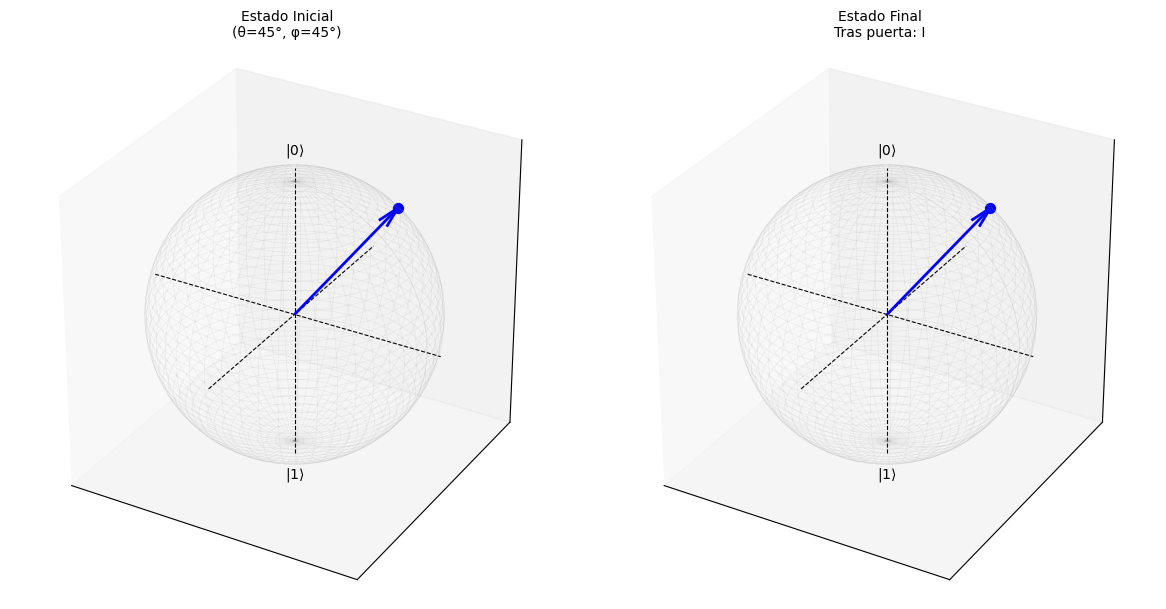

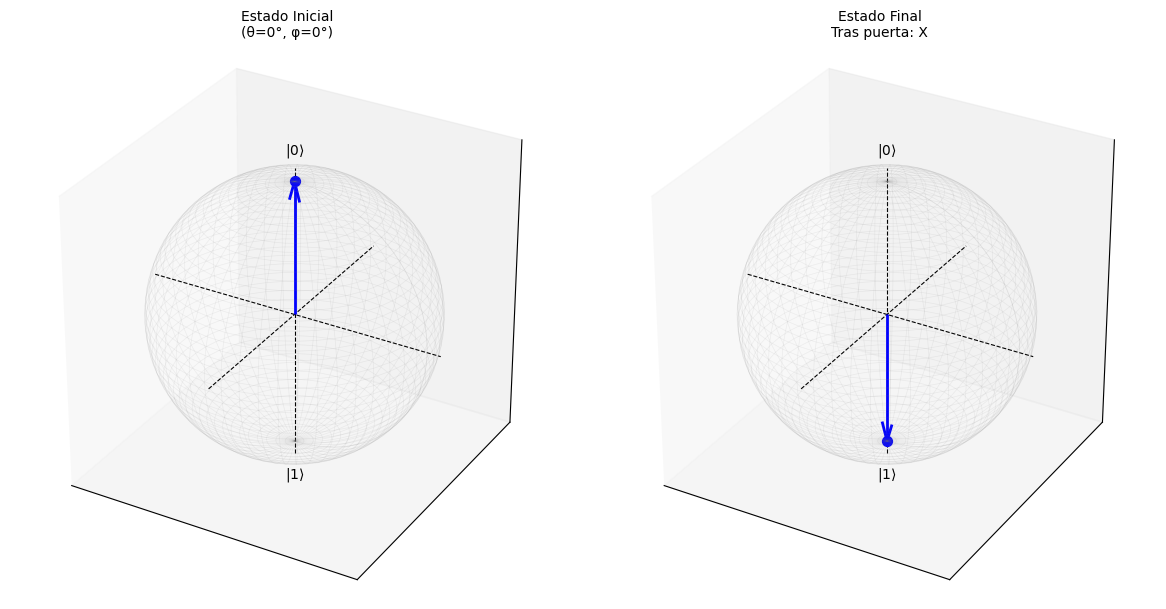

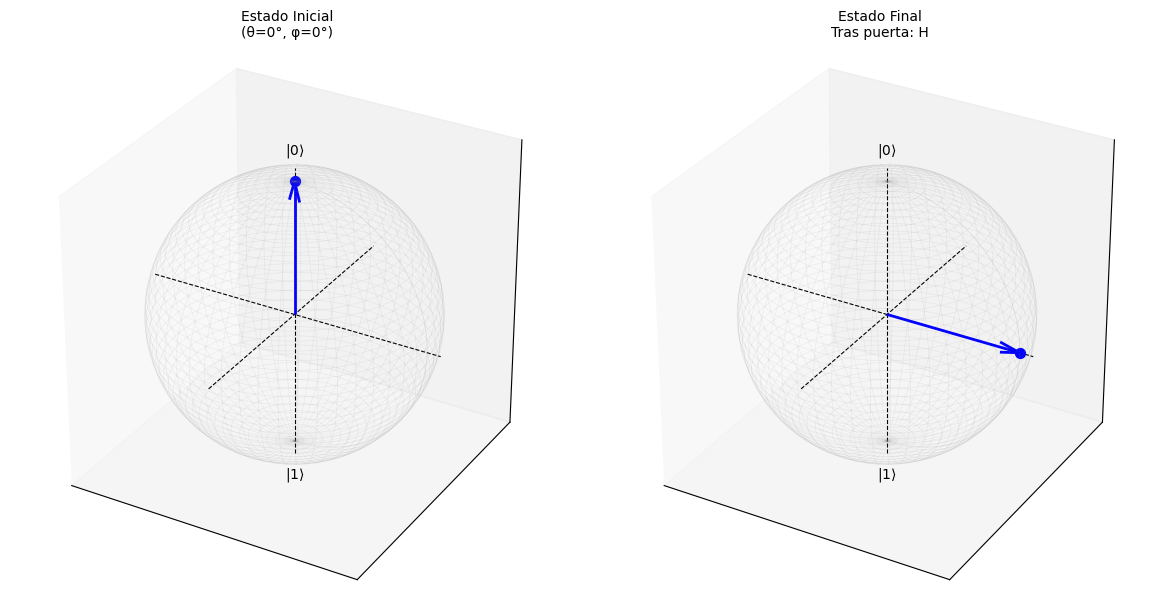

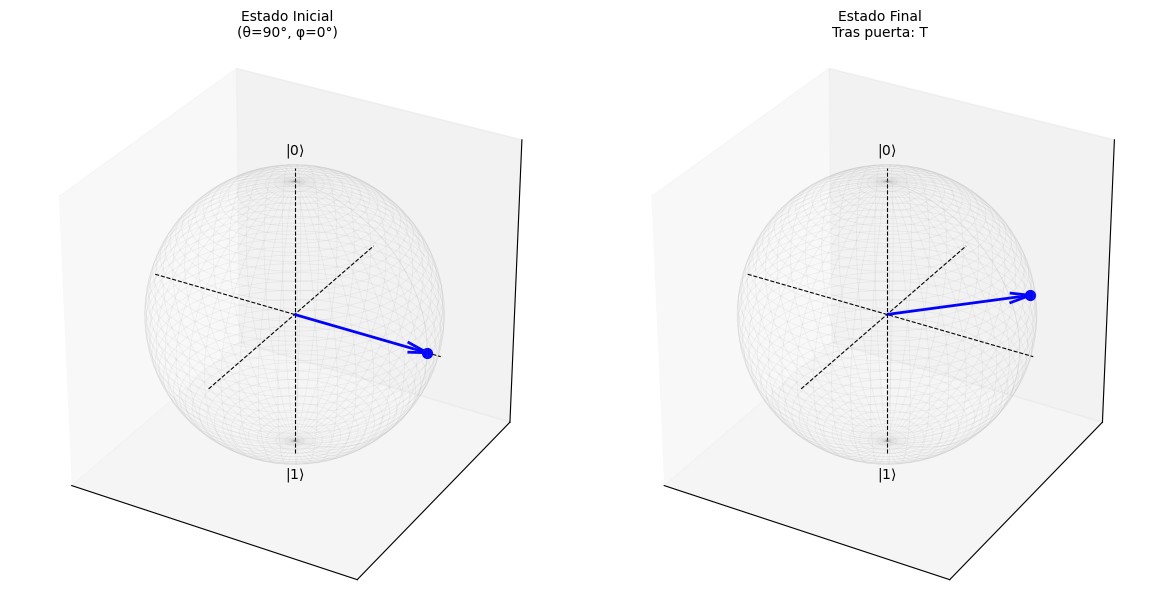

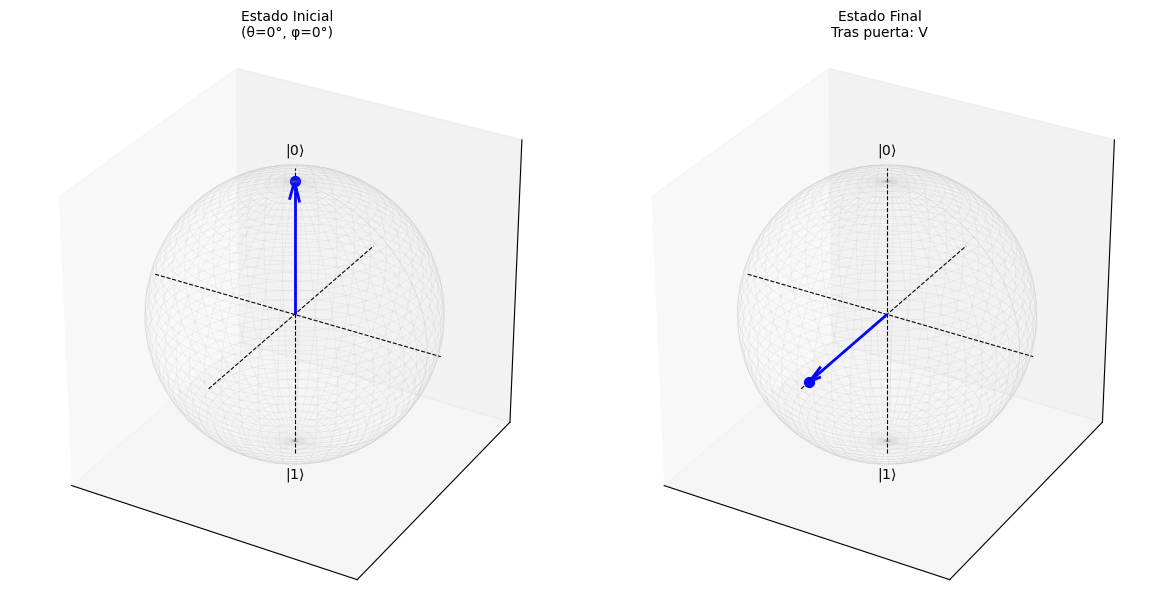

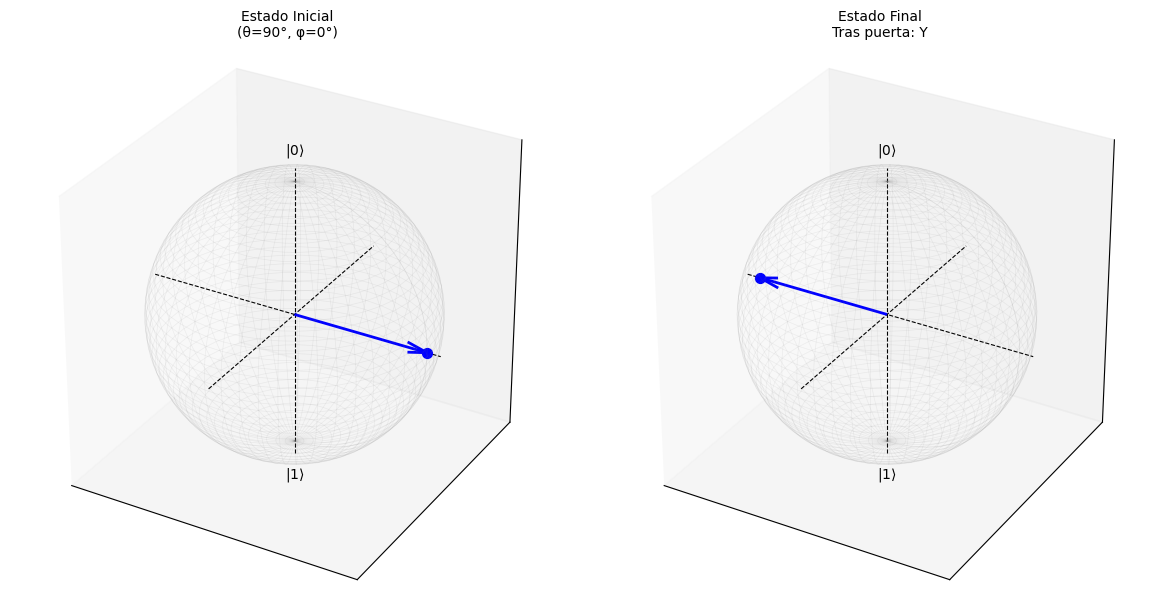

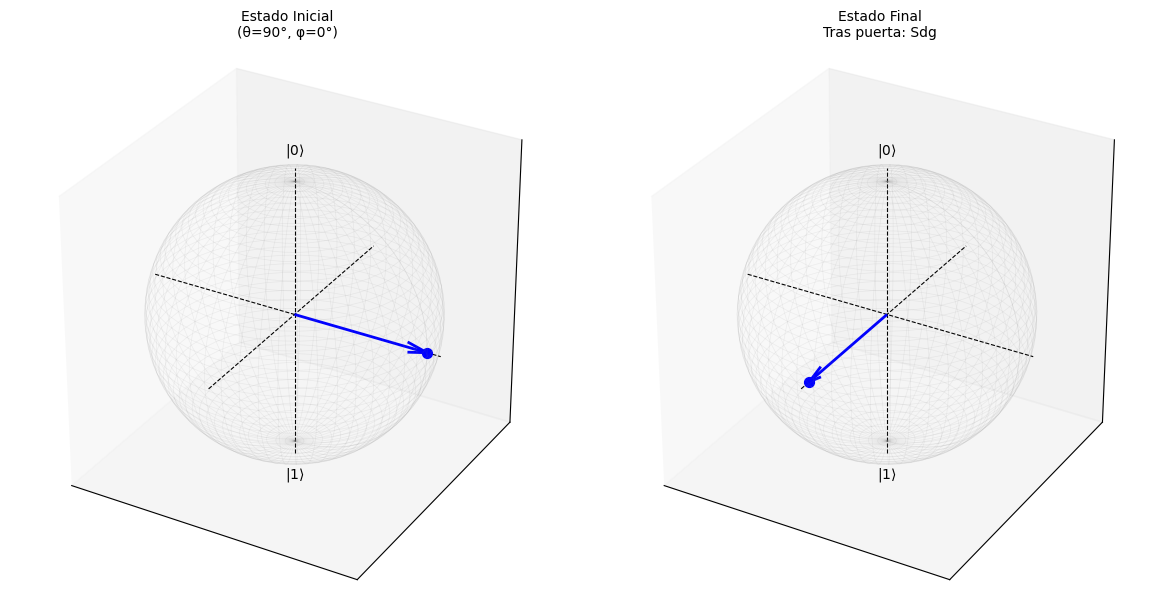

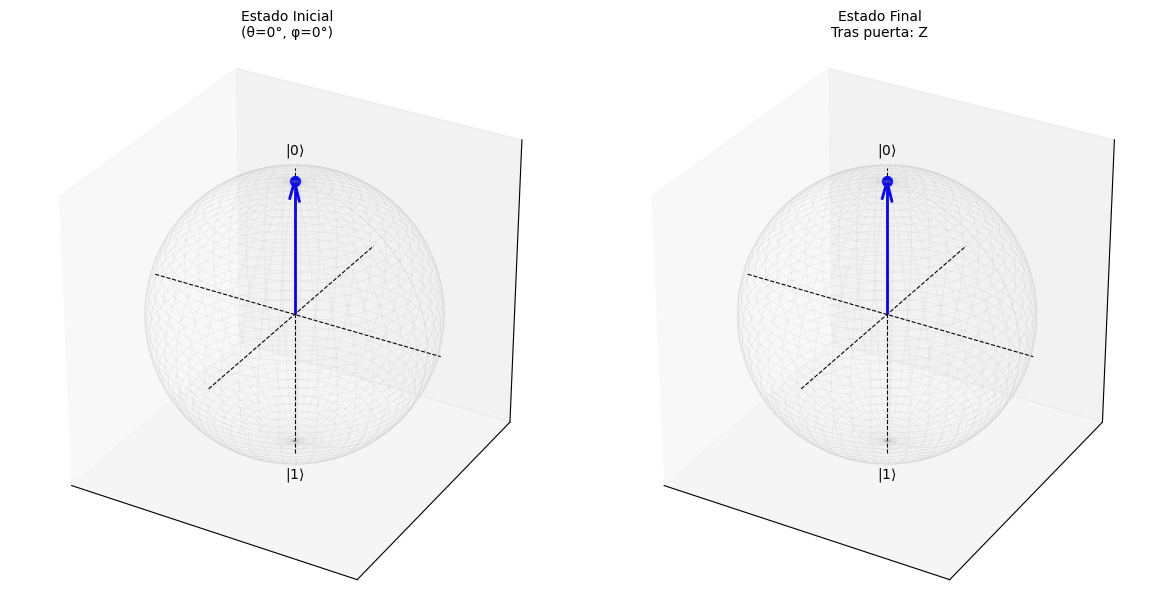

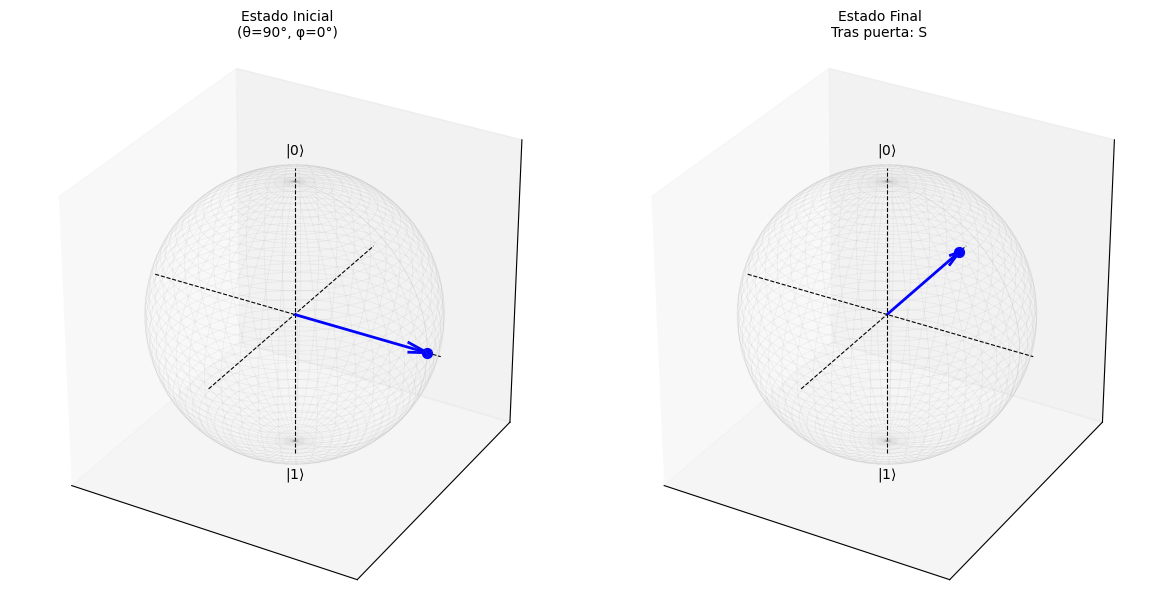

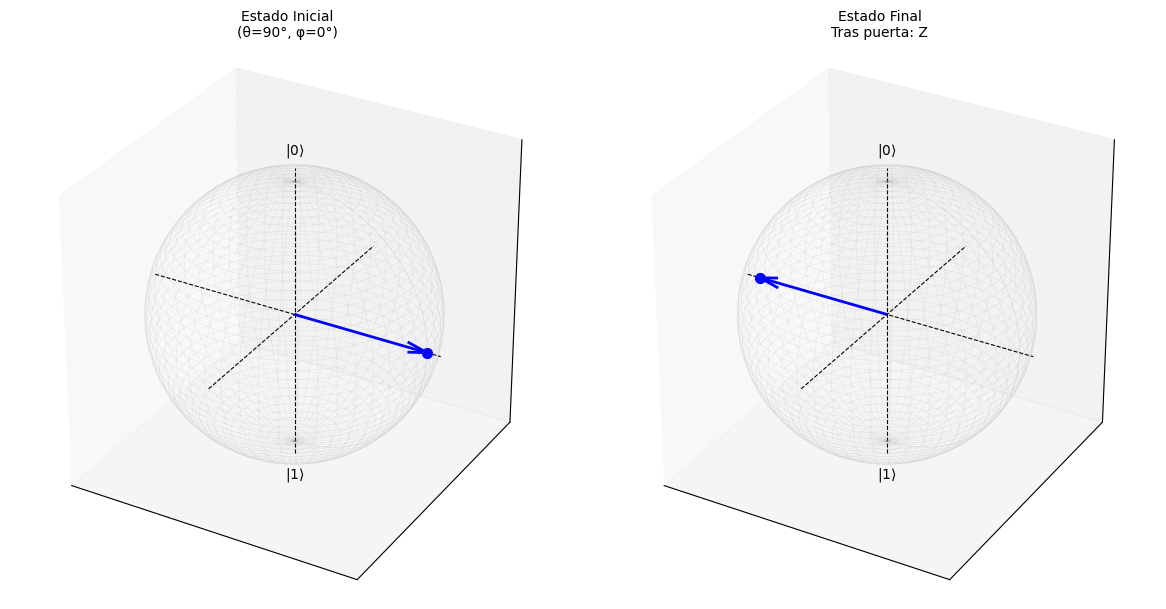

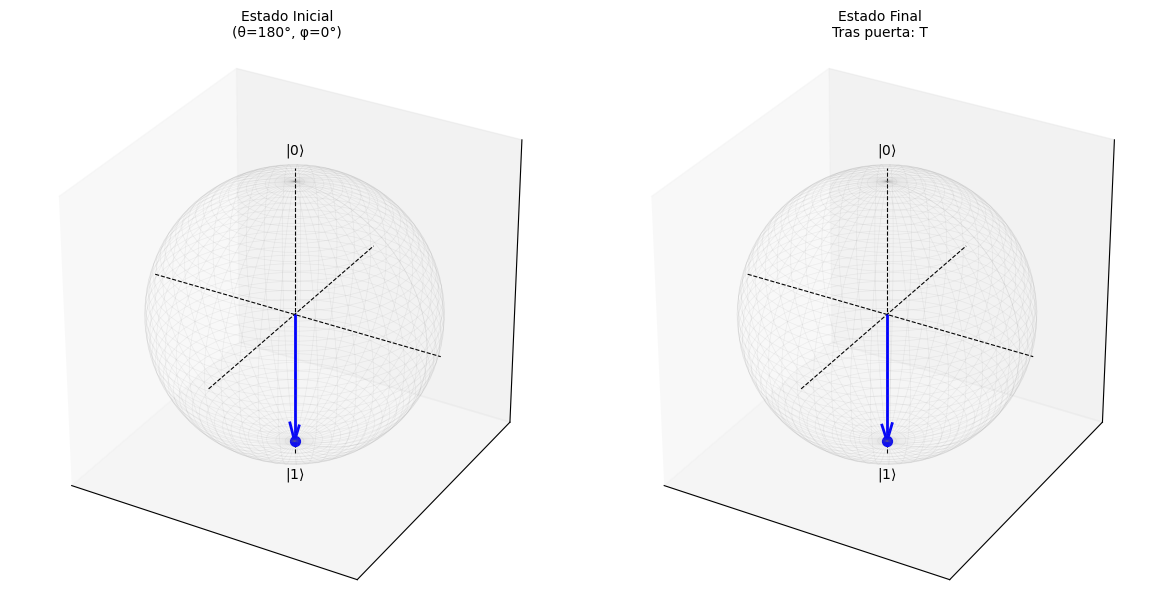

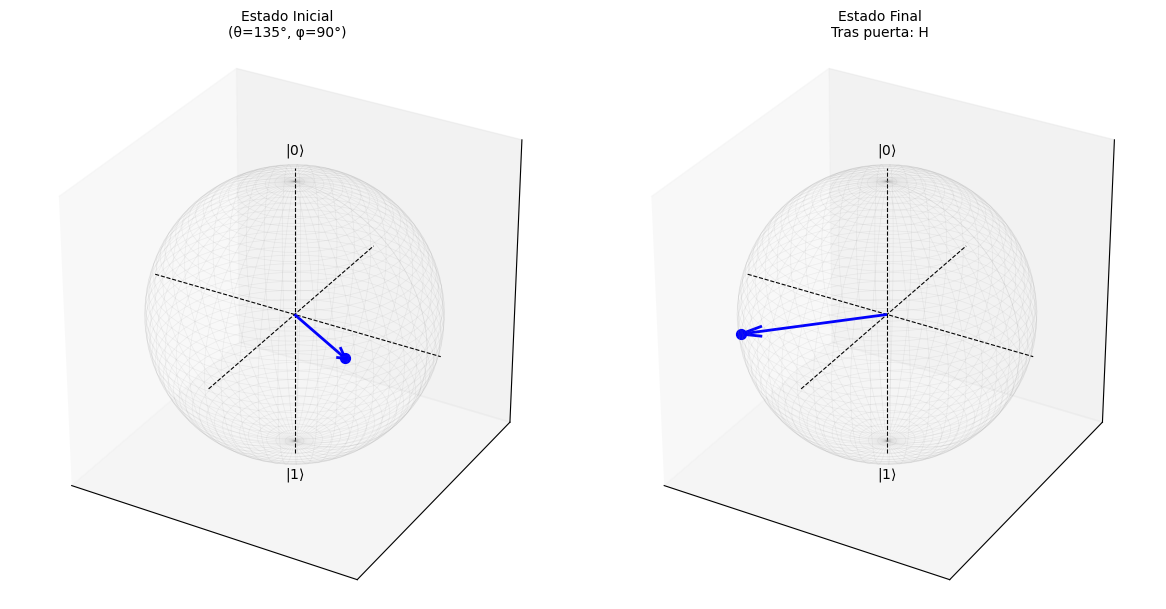

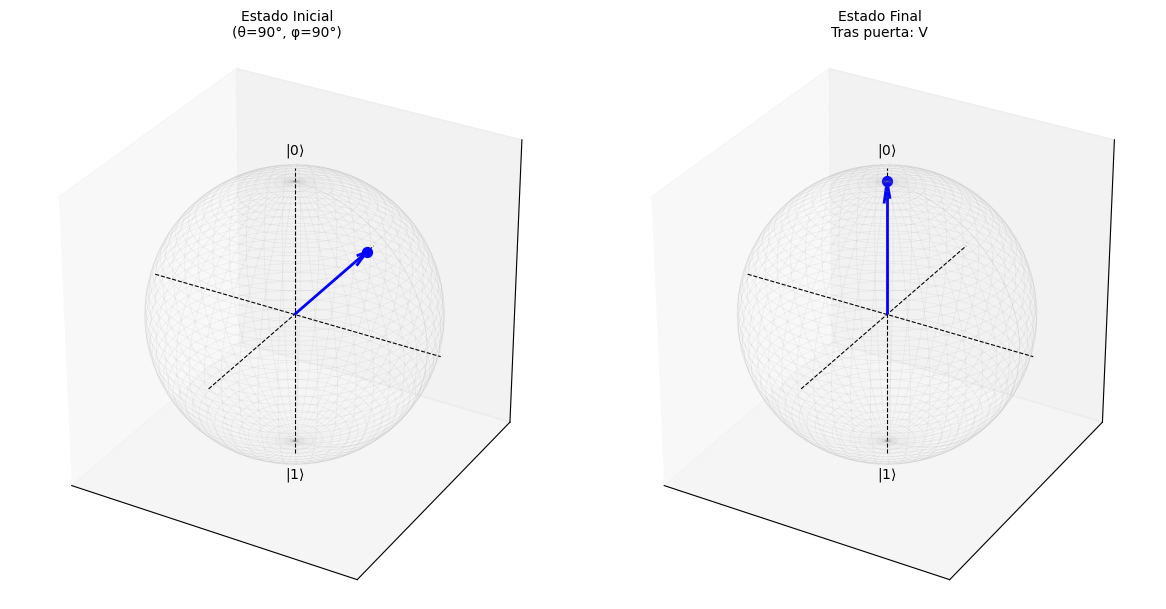

In [4]:
# Uso de puerta Identidad: el sistema mantiene el mismo estado
simular_qbit(45, 45, "I")

# Puerta X: Paso de |0> a |1>
simular_qbit(0, 0, "X")

# Puerta H: Creación de superposición partiendo del estado fundamental
simular_qbit(0, 0, "H")

# Puerta T sobre el ecuador de la esfera: desplaza el vector 45 grados en Phi
simular_qbit(90, 0, "T")

# Puerta V: Rotación de 90° sobre el eje X (lleva |0> al eje Y+)
simular_qbit(0, 0, "V")

# Puerta Y aplicada a un estado en el eje X
simular_qbit(90, 0, "Y")

# Puerta S adjunta: hace una rotación de 270° en Z
simular_qbit(90, 0, "Sdg")

# Aplicar Z al estado |0> no debería mover el vector visualmente
simular_qbit(0, 0, "Z")

# Puerta S sobre un estado generado por Hadamard
simular_qbit(90, 0, "S")

# Aplicar Z a un estado en el ecuador (pasa de X+ a X-)
simular_qbit(90, 0, "Z")

# Puerta T aplicada desde |1>
# Comprobar que en |1> la fase relativa tampoco es visible (fase global efectiva)
simular_qbit(180, 0, "T")

# Aplicar Hadamard a un estado que ya tiene una inclinación previa
simular_qbit(135, 90, "H")

# Aplicar la puerta V a un estado que ya está en el eje Y
simular_qbit(90, 90, "V")

In [5]:
# Controles
theta_input = widgets.FloatText(value=0.0, description='Theta (°):')
phi_input = widgets.FloatText(value=0.0, description='Phi (°):')
selector_puerta = widgets.Dropdown(
    options=['I', 'H', 'X', 'Y', 'Z', 'S', 'Sdg', 'T', 'Tdg', 'V', 'Vdg'],
    value='I',
    description='Puerta:',
)

# Renderizado
widgets.interact(simular_qbit, 
                 theta_deg=theta_input, 
                 phi_deg=phi_input, 
                 nombre_puerta=selector_puerta)

interactive(children=(FloatText(value=0.0, description='Theta (°):'), FloatText(value=0.0, description='Phi (°…

<function __main__.simular_qbit(theta_deg, phi_deg, nombre_puerta)>